# Olivia Rodrigo Production Evolution — A Data Engineering Analysis

This notebook builds a reproducible pipeline that tracks how Olivia Rodrigo's production quality and audio characteristics evolved across her three studio albums — **SOUR** (2021), **GUTS** (2023), and **you seem pretty sad for a girl so in love** (2026) — all produced by Dan Nigro, and tests whether that evolution correlates with audience engagement (Spotify popularity, chart performance).

**Structure:**
1. Data Ingestion
2. Data Cleaning / ETL
3. Exploratory Analysis
4. Engagement Correlation
5. (Code quality is applied throughout, not a separate section)

**A note on data provenance**, since it shapes everything below: Spotify deprecated public access to `/audio-features` and `/audio-analysis` for every app created after Nov 27, 2024 — there is no credential that unlocks it. Combined with the fact that no dataset anywhere can contain audio features for a June 2026 album, this notebook treats audio features as **manually/partially sourced** rather than pretending a clean API exists. Track identity data (names, order, duration) is sourced from Wikipedia rather than the Spotify API, and live Spotify data is used only transiently at runtime for popularity scores — per this project's Spotify Developer Terms compliance decision, raw Spotify API responses are never written to disk; only the final point-in-time popularity number (dated and attributed) flows into the processed dataset. See the Data Ingestion section for the full source-by-source breakdown.

## Setup

In [1]:
import os
import re
import time
import base64
from pathlib import Path
from datetime import datetime, timezone

import truststore
# Uses the OS certificate trust store instead of the bundled `certifi` list. Needed on
# machines where antivirus/network software (e.g. Avast Web Shield) does TLS inspection —
# it re-signs HTTPS traffic with a locally-generated root CA that Windows trusts but
# certifi doesn't. This makes Python trust what the OS already trusts; it does NOT
# disable certificate verification.
truststore.inject_into_ssl()

import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv

load_dotenv()

# Project paths, resolved relative to this notebook so it works regardless of the
# directory the Jupyter server was launched from.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print(f"Project root:     {PROJECT_ROOT}")
print(f"Raw data dir:      {RAW_DIR}")
print(f"Processed data dir: {PROCESSED_DIR}")

Project root:     D:\OR analysis
Raw data dir:      D:\OR analysis\data\raw
Processed data dir: D:\OR analysis\data\processed


## 1. Data Ingestion

Five sources feed this pipeline, each with a distinct role and distinct limitations:

| Source | Provides | Persisted to `/data/raw`? |
|---|---|---|
| Wikipedia (hardcoded, cited) | Track names, order, duration, bonus-track flags | Yes |
| Spotify Web API (Client Credentials) | Popularity score (live only) | No — Developer Terms prohibit indefinite storage of Spotify content; used in-memory and only the final dated snapshot reaches `/data/processed` |
| ReccoBeats (free, no key) | Full audio-feature set — SOUR + GUTS only, its catalog predates the 2026 album | Yes |
| GetSongBPM API | Tempo, key, time signature — currently blocked (Cloudflare) | Yes |
| Manual entry | Whatever ReccoBeats/GetSongBPM didn't cover — currently all of the 2026 album | Yes (template, blank until filled) |

Each source is wrapped behind its own small class/function so the pipeline is swappable — if a better free audio-feature API appears later, only the relevant block needs to change, not the downstream cleaning/analysis code.

### 1.1 Track identity (Wikipedia)

Spotify's own catalog endpoints (`Get Album`, `Get Album Tracks`) could technically supply this, but since track names/order/duration would then count as persisted Spotify Content under the Developer Terms, this project sources them from Wikipedia instead — publicly citable, and avoids the compliance question entirely for the one thing that has to live in a committed CSV either way.

In [2]:
def mmss_to_seconds(mmss: str) -> int:
    """Convert an 'M:SS' duration string to total seconds."""
    minutes, seconds = mmss.split(":")
    return int(minutes) * 60 + int(seconds)


# Canonical track listings, sourced from Wikipedia (accessed 2026-07-17):
#   https://en.wikipedia.org/wiki/Sour_(album)
#   https://en.wikipedia.org/wiki/Guts_(album)
#   https://en.wikipedia.org/wiki/You_Seem_Pretty_Sad_for_a_Girl_So_in_Love
#
# Deluxe/bonus-track rule (documented per project spec): bonus and deluxe tracks are
# INCLUDED, not dropped, but flagged via `is_bonus=True`. Downstream analysis can
# then choose standard-only or full-including-deluxe per chart without losing data.
ALBUMS_RAW = {
    "SOUR": {
        "release_date": "2021-05-21",
        "era": 1,
        "tracks": [
            (1, "Brutal", "2:23", False),
            (2, "Traitor", "3:49", False),
            (3, "Drivers License", "4:02", False),
            (4, "1 Step Forward, 3 Steps Back", "2:43", False),
            (5, "Deja Vu", "3:35", False),
            (6, "Good 4 U", "2:58", False),
            (7, "Enough for You", "3:22", False),
            (8, "Happier", "2:55", False),
            (9, "Jealousy, Jealousy", "2:53", False),
            (10, "Favorite Crime", "2:32", False),
            (11, "Hope Ur Ok", "3:29", False),
        ],
    },
    "GUTS": {
        "release_date": "2023-09-08",
        "era": 2,
        "tracks": [
            (1, "All-American Bitch", "2:45", False),
            (2, "Bad Idea Right?", "3:04", False),
            (3, "Vampire", "3:39", False),
            (4, "Lacy", "2:57", False),
            (5, "Ballad of a Homeschooled Girl", "3:23", False),
            (6, "Making the Bed", "3:18", False),
            (7, "Logical", "3:51", False),
            (8, "Get Him Back!", "3:31", False),
            (9, "Love Is Embarrassing", "2:34", False),
            (10, "The Grudge", "3:09", False),
            (11, "Pretty Isn't Pretty", "3:19", False),
            (12, "Teenage Dream", "3:42", False),
            # GUTS (spilled) deluxe edition, released 2024-03-22
            (13, "Obsessed", "2:50", True),
            (14, "Girl I've Always Been", "2:01", True),
            (15, "Scared of My Guitar", "4:23", True),
            (16, "Stranger", "3:12", True),
            (17, "So American", "2:49", True),
        ],
    },
    "you seem pretty sad for a girl so in love": {
        "release_date": "2026-06-12",
        "era": 3,
        "tracks": [
            (1, "Drop Dead", "3:44", False),
            (2, "Stupid Song", "3:29", False),
            (3, "Honeybee", "3:43", False),
            (4, "Maggots for Brains", "4:00", False),
            (5, "U + Me = <3", "4:07", False),
            (6, "My Way", "3:00", False),
            (7, "Purple", "4:00", False),
            (8, "The Cure", "4:57", False),
            (9, "Begged", "3:37", False),
            (10, "What's Wrong with Me (feat. Robert Smith)", "3:44", False),
            (11, "Less", "3:13", False),
            (12, "Expectations", "3:41", False),
            (13, "Cigarette Smoke", "5:40", False),
            # Bonus track added to the digital edition 2026-06-14
            (14, "Never Do", "3:43", True),
        ],
    },
}


def build_track_skeleton(albums_raw: dict) -> pd.DataFrame:
    """Flatten ALBUMS_RAW into one row per track — the spine every other source joins onto."""
    rows = []
    for album, meta in albums_raw.items():
        for track_number, title, duration, is_bonus in meta["tracks"]:
            rows.append({
                "album": album,
                "era": meta["era"],
                "release_date": meta["release_date"],
                "track_number": track_number,
                "title": title,
                "duration_sec": mmss_to_seconds(duration),
                "is_bonus": is_bonus,
            })
    return pd.DataFrame(rows)


track_skeleton = build_track_skeleton(ALBUMS_RAW)
print(f"Loaded {len(track_skeleton)} tracks across {track_skeleton['album'].nunique()} albums")
track_skeleton.head()

Loaded 42 tracks across 3 albums


,album,era,release_date,track_number,title,duration_sec,is_bonus
0,SOUR,1,2021-05-21,1,Brutal,143,False
1,SOUR,1,2021-05-21,2,Traitor,229,False
2,SOUR,1,2021-05-21,3,Drivers License,242,False
3,SOUR,1,2021-05-21,4,"1 Step Forward, 3 Steps Back",163,False
4,SOUR,1,2021-05-21,5,Deja Vu,215,False


### 1.2 Spotify Web API — popularity (live, not persisted)

Uses the **Client Credentials flow** (app-only, no user login) since everything pulled here — search, track popularity — is public catalog data, not user-specific data. This deliberately does *not* request any OAuth scopes.

This same client is also used to demonstrate, live, that `/audio-features` is dead: rather than asserting the Nov 2024 deprecation as a fact and skipping the call, it actually makes the request and reports whatever Spotify returns. Every request goes through a shared retry helper that respects `Retry-After` on HTTP 429 with exponential backoff, per Spotify's rate-limit guidance.

In [3]:
class SpotifyAuthError(Exception):
    """Raised when Spotify credentials are missing or rejected."""


class SpotifyClient:
    """
    Thin wrapper around the Spotify Web API's Client Credentials flow.

    Used ONLY for public catalog data (track search, popularity) — no user-specific
    scopes are requested, per Spotify's own guidance to reserve Client Credentials
    for non-user data.

    Per this project's Developer Terms compliance decision (see markdown above),
    this client is a live, in-memory lookup only. Nothing it returns is written to
    disk as a raw dump here; only a final popularity snapshot (numeric score + fetch
    date) is allowed to flow into the processed dataset later in the pipeline.
    """

    TOKEN_URL = "https://accounts.spotify.com/api/token"
    API_BASE = "https://api.spotify.com/v1"

    def __init__(self, client_id: str = None, client_secret: str = None):
        self.client_id = client_id or os.getenv("SPOTIFY_CLIENT_ID")
        self.client_secret = client_secret or os.getenv("SPOTIFY_CLIENT_SECRET")
        self._token = None
        self._token_expires_at = 0.0

    @property
    def is_configured(self) -> bool:
        return bool(self.client_id and self.client_secret)

    def _get_access_token(self) -> str:
        """Fetch (and cache) an app-only access token, refreshing shortly before it expires."""
        if not self.is_configured:
            raise SpotifyAuthError(
                "SPOTIFY_CLIENT_ID / SPOTIFY_CLIENT_SECRET not set in .env."
            )
        if self._token and time.time() < self._token_expires_at - 30:
            return self._token

        auth_bytes = f"{self.client_id}:{self.client_secret}".encode("utf-8")
        auth_header = base64.b64encode(auth_bytes).decode("utf-8")
        response = requests.post(
            self.TOKEN_URL,
            headers={
                "Authorization": f"Basic {auth_header}",
                "Content-Type": "application/x-www-form-urlencoded",
            },
            data={"grant_type": "client_credentials"},
            timeout=10,
        )
        if response.status_code != 200:
            raise SpotifyAuthError(
                f"Spotify token request failed ({response.status_code}): {response.text}"
            )
        payload = response.json()
        self._token = payload["access_token"]
        self._token_expires_at = time.time() + payload.get("expires_in", 3600)
        return self._token

    def _request(self, method: str, path: str, **kwargs):
        """
        Authenticated request with exponential backoff on HTTP 429, honoring the
        Retry-After header per Spotify's rate-limit guidance. Returns None (rather
        than raising) if retries are exhausted, so a single flaky call can't crash
        the whole ingestion run.
        """
        token = self._get_access_token()
        headers = kwargs.pop("headers", {})
        headers["Authorization"] = f"Bearer {token}"

        backoff = 1.0
        for attempt in range(5):
            response = requests.request(
                method, f"{self.API_BASE}{path}", headers=headers, timeout=10, **kwargs
            )
            if response.status_code == 429:
                retry_after = int(response.headers.get("Retry-After", backoff))
                print(f"    Rate limited by Spotify — waiting {retry_after}s (attempt {attempt + 1}/5)")
                time.sleep(retry_after)
                backoff *= 2
                continue
            return response
        print("    Gave up after repeated 429s from Spotify.")
        return None

    def search_track(self, title: str, artist: str = "Olivia Rodrigo"):
        """Resolve a track title to a Spotify track ID via the Search endpoint."""
        try:
            response = self._request(
                "GET", "/search",
                params={"q": f"track:{title} artist:{artist}", "type": "track", "limit": 1},
            )
        except SpotifyAuthError as exc:
            print(f"    Spotify auth unavailable: {exc}")
            return None
        if response is None:
            return None
        if response.status_code != 200:
            print(f"    Spotify search failed for '{title}' ({response.status_code}): {response.text[:200]}")
            return None
        items = response.json().get("tracks", {}).get("items", [])
        return items[0]["id"] if items else None

    def get_popularity_batch(self, track_ids: list) -> dict:
        """
        Fetch popularity for up to 50 track IDs at once via Get Several Tracks.
        `popularity` is a live field here — unlike the deprecated copy nested inside
        Get Album's track list.
        """
        popularity = {}
        clean_ids = [t for t in track_ids if t]
        for i in range(0, len(clean_ids), 50):
            batch = clean_ids[i:i + 50]
            try:
                response = self._request("GET", "/tracks", params={"ids": ",".join(batch)})
            except SpotifyAuthError as exc:
                print(f"    Spotify auth unavailable: {exc}")
                return popularity
            if response is None or response.status_code != 200:
                status = response.status_code if response is not None else "no response"
                print(f"    Spotify Get Several Tracks failed ({status})")
                continue
            for track in response.json().get("tracks", []):
                if track:
                    popularity[track["id"]] = track["popularity"]
        return popularity

    def attempt_audio_features(self, sample_track_id: str):
        """
        Demonstrates, live, rather than assumes, the Nov 2024 deprecation: calls
        /audio-features for one real track ID and reports exactly what comes back.
        Expected result for any app created after Nov 27 2024: HTTP 403.
        """
        try:
            response = self._request("GET", f"/audio-features/{sample_track_id}")
        except SpotifyAuthError as exc:
            print(f"    Spotify auth unavailable: {exc}")
            return None
        if response is None:
            return None
        if response.status_code == 200:
            print("    /audio-features succeeded — this app has pre-Nov-2024 extended quota.")
            return response.json()
        print(
            f"    /audio-features returned {response.status_code} as expected for a "
            f"post-deprecation app: {response.text[:200]}"
        )
        return None

In [4]:
spotify = SpotifyClient()
spotify_popularity_snapshot = pd.DataFrame(columns=["title", "album", "spotify_popularity", "fetched_on"])

if not spotify.is_configured:
    print(
        "No Spotify credentials found in .env — skipping live Spotify calls entirely.\n"
        "Popularity scores will be left blank in the processed dataset. To fill them in,\n"
        "add SPOTIFY_CLIENT_ID / SPOTIFY_CLIENT_SECRET to .env and re-run this cell."
    )
else:
    try:
        spotify._get_access_token()
        print("Spotify authentication succeeded.\n")
    except SpotifyAuthError as exc:
        print(f"Spotify authentication failed: {exc}")
        spotify = SpotifyClient(client_id=None, client_secret=None)  # force is_configured False below

if spotify.is_configured:
    print("Resolving Spotify track IDs (search, in-memory only)...")
    spotify_track_ids = {}
    for _, row in track_skeleton.iterrows():
        spotify_track_ids[(row["album"], row["title"])] = spotify.search_track(row["title"])
        time.sleep(0.05)  # light client-side pacing on top of the 429 backoff in _request

    resolved_ids = [tid for tid in spotify_track_ids.values() if tid]
    print(f"Resolved {len(resolved_ids)}/{len(track_skeleton)} tracks to Spotify IDs.")

    print("\nFetching popularity scores (live, not cached to disk)...")
    popularity_by_id = spotify.get_popularity_batch(resolved_ids)

    fetched_on = datetime.now(timezone.utc).strftime("%Y-%m-%d")
    rows = [
        {"title": title, "album": album, "spotify_popularity": popularity_by_id[track_id], "fetched_on": fetched_on}
        for (album, title), track_id in spotify_track_ids.items()
        if track_id and track_id in popularity_by_id
    ]
    spotify_popularity_snapshot = pd.DataFrame(rows)
    print(f"Got popularity for {len(spotify_popularity_snapshot)} tracks.")

    if resolved_ids:
        print("\nConfirming /audio-features status on a live sample track...")
        spotify.attempt_audio_features(resolved_ids[0])

spotify_popularity_snapshot.head()

No Spotify credentials found in .env — skipping live Spotify calls entirely.
Popularity scores will be left blank in the processed dataset. To fill them in,
add SPOTIFY_CLIENT_ID / SPOTIFY_CLIENT_SECRET to .env and re-run this cell.


,title,album,spotify_popularity,fetched_on


### 1.3 ReccoBeats — full audio-feature set (SOUR + GUTS only)

Discovered and live-tested mid-project (2026-07-19) as a genuinely free, no-API-key alternative: given a Spotify track ID, ReccoBeats returns the complete Spotify-equivalent feature set (acousticness, danceability, energy, instrumentalness, key, loudness, speechiness, tempo, valence). Confirmed directly: it covers SOUR (tested a hit single and a deep cut) and GUTS, but returns no match at all for 2026-album tracks — its catalog is necessarily frozen before that album existed, the same ceiling every other source in this project hits.

Its response includes an ISRC and a live popularity figure matching Spotify's own, so this data clearly derives from Spotify in some way; ReccoBeats' own public docs don't state whether it's independently computed or a cached mirror, or spell out redistribution terms. Persisting it to `/data/raw` is a deliberate project decision made with that uncertainty acknowledged — not a Spotify Developer Terms question, since it isn't fetched through this project's own Spotify agreement.

Track-to-Spotify-ID resolution uses live Spotify search when `SPOTIFY_CLIENT_ID`/`SECRET` are configured, falling back to a hardcoded map (sourced from kworb.net, a public Spotify chart-tracking site) for SOUR/GUTS so this section works even without Spotify credentials.

In [5]:
class ReccoBeatsSource:
    """
    Wrapper around ReccoBeats (https://api.reccobeats.com/v1) — a free, no-API-key
    Spotify-audio-features mirror/replacement. Live-tested (2026-07-19): returns the
    full Spotify-equivalent feature set given a Spotify track ID, but its catalog is
    frozen before the 2026 album existed — confirmed by testing real 2026-album track
    IDs and getting no match. So this only ever fills in SOUR/GUTS. See the markdown
    above for the data-provenance caveat this project accepted when persisting it.
    """

    BASE_URL = "https://api.reccobeats.com/v1"

    def __init__(self):
        self._blocked_reason = None

    @property
    def is_blocked(self) -> bool:
        return self._blocked_reason is not None

    def lookup_by_spotify_id(self, spotify_track_id: str):
        if self.is_blocked or not spotify_track_id:
            return None
        try:
            resolve = requests.get(f"{self.BASE_URL}/track", params={"ids": spotify_track_id}, timeout=10)
        except requests.RequestException as exc:
            print(f"    ReccoBeats request error resolving {spotify_track_id}: {exc}")
            return None
        if resolve.status_code == 429:
            print("    ReccoBeats rate limited — stopping for the rest of this run.")
            self._blocked_reason = "Rate limited (429)"
            return None
        if resolve.status_code != 200:
            print(f"    ReccoBeats track lookup failed for {spotify_track_id} ({resolve.status_code})")
            return None

        matches = resolve.json().get("content", [])
        if not matches:
            return None  # not in their catalog — expected for the 2026 album
        reccobeats_id = matches[0]["id"]

        try:
            features = requests.get(f"{self.BASE_URL}/track/{reccobeats_id}/audio-features", timeout=10)
        except requests.RequestException as exc:
            print(f"    ReccoBeats request error fetching features for {spotify_track_id}: {exc}")
            return None
        if features.status_code != 200:
            print(f"    ReccoBeats audio-features failed for {spotify_track_id} ({features.status_code})")
            return None

        payload = features.json()
        return {
            "energy": payload.get("energy"),
            "loudness": payload.get("loudness"),
            "valence": payload.get("valence"),
            "danceability": payload.get("danceability"),
            "acousticness": payload.get("acousticness"),
            "instrumentalness": payload.get("instrumentalness"),
            "speechiness": payload.get("speechiness"),
            "tempo": payload.get("tempo"),
            "key": payload.get("key"),
        }


# Known Spotify track IDs for SOUR + GUTS, sourced from kworb.net's public Spotify
# chart-tracking pages (accessed 2026-07-19) — used so this section works even without
# Spotify credentials configured. If SPOTIFY_CLIENT_ID/SECRET *are* set, live search is
# used instead (see resolve_spotify_id below), so this map only needs to be a floor.
SPOTIFY_TRACK_IDS_KNOWN = {
    ("SOUR", "Brutal"): "6SRsiMl7w1USE4mFqrOhHC",
    ("SOUR", "Traitor"): "5CZ40GBx1sQ9agT82CLQCT",
    ("SOUR", "Drivers License"): "5wANPM4fQCJwkGd4rN57mH",
    ("SOUR", "1 Step Forward, 3 Steps Back"): "4wcBRRpIfesgcyUtis7PEg",
    ("SOUR", "Deja Vu"): "6HU7h9RYOaPRFeh0R3UeAr",
    ("SOUR", "Good 4 U"): "4ZtFanR9U6ndgddUvNcjcG",
    ("SOUR", "Enough for You"): "2TOzTqQXNmR2zDJXihjZ2e",
    ("SOUR", "Happier"): "2tGvwE8GcFKwNdAXMnlbfl",
    ("SOUR", "Jealousy, Jealousy"): "0MMyJUC3WNnFS1lit5pTjk",
    ("SOUR", "Favorite Crime"): "5JCoSi02qi3jJeHdZXMmR8",
    ("SOUR", "Hope Ur Ok"): "1zejeOnykpCoyVSit6Bwp3",
    ("GUTS", "All-American Bitch"): "34sOdxWu9FljH84UXdRwu1",
    ("GUTS", "Bad Idea Right?"): "3IX0yuEVvDbnqUwMBB3ouC",
    ("GUTS", "Vampire"): "1kuGVB7EU95pJObxwvfwKS",
    ("GUTS", "Lacy"): "6QT6j7rKt7Vk3IuV2AUO9W",
    ("GUTS", "Ballad of a Homeschooled Girl"): "5sp71CUt0jXRNqHblPGp7b",
    ("GUTS", "Making the Bed"): "5CscrLqFBgPfZR8fGtikov",
    ("GUTS", "Logical"): "53dtP2iUMvaF28JZcHnFuU",
    ("GUTS", "Get Him Back!"): "2gyxAWHebV7xPYVxqoi86f",
    ("GUTS", "Love Is Embarrassing"): "26QLJMK8G0M06sk7h7Fkse",
    ("GUTS", "The Grudge"): "3Nl5OkkmS5DaBZvuYofpAt",
    ("GUTS", "Pretty Isn't Pretty"): "6W9l02gRsXVxzIuQC1oc1X",
    ("GUTS", "Teenage Dream"): "7fesNTgTEMEH0ye8MOgEDY",
    ("GUTS", "Obsessed"): "6tNgRQ0K2NYZ0Rb9l9DzL8",
    ("GUTS", "Girl I've Always Been"): "0bJAmhSAeMSfsyazOEUVFf",
    ("GUTS", "Scared of My Guitar"): "7JqH46zlr7XV7vMBt4slE6",
    ("GUTS", "Stranger"): "2U3jOPfO4wZZFaaWS4Dcj6",
    ("GUTS", "So American"): "5Jh1i0no3vJ9u4deXkb4aV",
}


def resolve_spotify_id(album: str, title: str):
    """Live Spotify search if credentials are configured, else the known-ID map above."""
    if spotify.is_configured:
        return spotify.search_track(title)
    return SPOTIFY_TRACK_IDS_KNOWN.get((album, title))


reccobeats = ReccoBeatsSource()
reccobeats_rows = []

print("Looking up audio features via ReccoBeats...")
for _, row in track_skeleton.iterrows():
    spotify_id = resolve_spotify_id(row["album"], row["title"])
    result = reccobeats.lookup_by_spotify_id(spotify_id) if spotify_id else None
    reccobeats_rows.append({"album": row["album"], "title": row["title"], **(result or {})})
    time.sleep(0.2)

reccobeats_df = pd.DataFrame(reccobeats_rows)
matched = reccobeats_df["energy"].notna().sum() if "energy" in reccobeats_df.columns else 0
print(f"Matched {matched}/{len(track_skeleton)} tracks on ReccoBeats "
      f"(expected: SOUR + GUTS only — its catalog predates the 2026 album).")
reccobeats_df.head()

Looking up audio features via ReccoBeats...


Matched 28/42 tracks on ReccoBeats (expected: SOUR + GUTS only — its catalog predates the 2026 album).


,album,title,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,tempo,key
0,SOUR,Brutal,0.526,-6.446,0.2800,0.672,0.0311,0.000001,0.0599,123.999,4.0
1,SOUR,Traitor,0.339,-7.885,0.0849,0.380,0.6910,0.000000,0.0338,100.607,3.0
2,SOUR,Drivers License,0.431,-8.810,0.1370,0.561,0.7680,0.000014,0.0578,143.875,10.0
3,SOUR,"1 Step Forward, 3 Steps Back",0.203,-12.627,0.4190,0.473,0.9410,0.000000,0.1020,168.884,2.0
4,SOUR,Deja Vu,0.612,-7.222,0.1780,0.442,0.5840,0.000006,0.1120,180.917,2.0


### 1.4 GetSongBPM — tempo, key, time signature (persisted, currently blocked)

Not Spotify content, so no storage restriction applies — this is written straight to `/data/raw`, and only fills gaps ReccoBeats left.

**Live result:** GetSongBPM's endpoint sits behind Cloudflare bot protection and returns an HTML JS-challenge page (HTTP 403) to plain server-side requests, independent of API key validity — confirmed by testing directly against the endpoint outside this notebook. This project doesn't attempt to work around Cloudflare's challenge (that would mean impersonating a browser to bypass bot protection), so `GetSongBPMSource` detects this condition once and fails fast rather than retrying it per track.

In [6]:
class GetSongBPMSource:
    """
    Wrapper around the free GetSongBPM API (https://getsongbpm.com/api).
    Provides tempo, key, and time signature — NOT the full Spotify-style feature set
    (no energy, loudness, valence, instrumentalness, or speechiness; those stay manual).

    GetSongBPM's endpoint sits behind Cloudflare bot protection, which can return an
    HTML JS-challenge page (HTTP 403) to any plain server-side request regardless of
    API key validity. This is detected explicitly and treated as a fail-fast condition
    for the whole source, rather than retried per track — attempting to work around
    Cloudflare's challenge would mean impersonating a browser to bypass bot protection,
    which this project won't do. When blocked, remaining audio features stay manual.
    """

    SEARCH_URL = "https://api.getsongbpm.com/search/"

    def __init__(self, api_key: str = None):
        self.api_key = api_key or os.getenv("GETSONGBPM_API_KEY")
        self._blocked_reason = None

    @property
    def is_configured(self) -> bool:
        return bool(self.api_key)

    @property
    def is_blocked(self) -> bool:
        return self._blocked_reason is not None

    def lookup(self, title: str, artist: str = "Olivia Rodrigo", _retry: bool = True):
        if not self.is_configured or self.is_blocked:
            return None
        try:
            response = requests.get(
                self.SEARCH_URL,
                params={
                    "api_key": self.api_key,
                    "type": "song",
                    "lookup": f"song:{title} artist:{artist}",
                },
                timeout=10,
            )
        except requests.RequestException as exc:
            print(f"    GetSongBPM request error for '{title}': {exc}")
            return None

        if response.status_code == 429 and _retry:
            retry_after = int(response.headers.get("Retry-After", 5))
            print(f"    GetSongBPM rate limited — waiting {retry_after}s")
            time.sleep(retry_after)
            return self.lookup(title, artist, _retry=False)

        if response.status_code == 403 and "cloudflare" in response.text.lower():
            self._blocked_reason = (
                "GetSongBPM's endpoint returned a Cloudflare bot-challenge page (HTTP 403) "
                "instead of JSON — this happens for any plain server-side request, "
                "independent of API key validity. Treating this source as unavailable for "
                "the rest of this run; tempo/key fall through to manual entry."
            )
            print(f"    {self._blocked_reason}")
            return None

        if response.status_code != 200:
            print(f"    GetSongBPM lookup failed for '{title}' ({response.status_code})")
            return None

        try:
            results = response.json().get("search", [])
        except ValueError:
            print(f"    GetSongBPM returned a non-JSON payload for '{title}' — skipping")
            return None
        if not isinstance(results, list) or not results:
            return None

        match = results[0]
        return {
            "tempo": match.get("tempo"),
            "key": match.get("key_of"),
            "time_signature": match.get("time_sig"),
            "danceability": match.get("danceability"),
            "acousticness": match.get("acousticness"),
        }


getsongbpm = GetSongBPMSource()
getsongbpm_rows = []

if getsongbpm.is_configured:
    print("Looking up tempo/key via GetSongBPM (one request per second, free-tier pacing)...")
    for _, row in track_skeleton.iterrows():
        if getsongbpm.is_blocked:
            getsongbpm_rows.append({"album": row["album"], "title": row["title"]})
            continue
        result = getsongbpm.lookup(row["title"])
        getsongbpm_rows.append({"album": row["album"], "title": row["title"], **(result or {})})
        if not getsongbpm.is_blocked:
            time.sleep(1)
    getsongbpm_df = pd.DataFrame(getsongbpm_rows)
    matched = getsongbpm_df["tempo"].notna().sum() if "tempo" in getsongbpm_df.columns else 0
    print(f"Matched {matched}/{len(track_skeleton)} tracks on GetSongBPM.")
else:
    print("No GETSONGBPM_API_KEY set — skipping. Tempo/key will be left for manual entry.")
    getsongbpm_df = pd.DataFrame(
        columns=["album", "title", "tempo", "key", "time_signature", "danceability", "acousticness"]
    )

getsongbpm_df.head()

Looking up tempo/key via GetSongBPM (one request per second, free-tier pacing)...


    GetSongBPM's endpoint returned a Cloudflare bot-challenge page (HTTP 403) instead of JSON — this happens for any plain server-side request, independent of API key validity. Treating this source as unavailable for the rest of this run; tempo/key fall through to manual entry.
Matched 0/42 tracks on GetSongBPM.


,album,title
0,SOUR,Brutal
1,SOUR,Traitor
2,SOUR,Drivers License
3,SOUR,"1 Step Forward, 3 Steps Back"
4,SOUR,Deja Vu


### 1.5 Merge sources + manual template + raw CSV export

Merges the Wikipedia track spine with ReccoBeats first, then GetSongBPM filling only whatever gaps ReccoBeats left, then adds blank columns for anything neither source covers, and writes one CSV per album to `/data/raw`. The `notes` column documents the source per row — either where a value came from, or how to fill it in — so methodology stays traceable and consistent across all three albums.

In [7]:
# Coverage varies by source and by what's currently reachable (GetSongBPM is blocked;
# neither source has ever covered the 2026 album) — nothing here is hard-guaranteed
# manual-only by design, so this is one list rather than a manual/partial split.
AUDIO_FEATURE_COLUMNS = [
    "energy", "loudness", "valence", "danceability", "acousticness",
    "instrumentalness", "speechiness", "tempo", "key", "time_signature",
]

raw_df = track_skeleton.merge(reccobeats_df, on=["album", "title"], how="left")
raw_df = raw_df.merge(getsongbpm_df, on=["album", "title"], how="left", suffixes=("", "_gsbpm"))

# GetSongBPM only fills whatever gaps ReccoBeats left — defensive design that keeps
# working automatically if ReccoBeats' coverage ever narrows or GetSongBPM's Cloudflare
# block ever lifts, without this merge logic needing to change.
for col in AUDIO_FEATURE_COLUMNS:
    gsbpm_col = f"{col}_gsbpm"
    if gsbpm_col in raw_df.columns:
        raw_df[col] = raw_df[col].fillna(raw_df[gsbpm_col])
        raw_df = raw_df.drop(columns=[gsbpm_col])
    elif col not in raw_df.columns:
        raw_df[col] = np.nan


def _row_note(row):
    if pd.notna(row.get("energy")):
        return "Audio features from ReccoBeats (api.reccobeats.com), matched via Spotify track ID."
    return (
        "Fill blank audio-feature columns by looking up '<title> Olivia Rodrigo' on a tool "
        "like tunebat.com or chosic.com and recording the displayed values. Note which tool "
        "you used per row if it varies, for reproducibility."
    )


raw_df["notes"] = raw_df.apply(_row_note, axis=1)

print("Column completeness before manual entry:")
for col in AUDIO_FEATURE_COLUMNS:
    present = raw_df[col].notna().sum()
    print(f"  {col:16s} {present:2d}/{len(raw_df)} filled")

for album in raw_df["album"].unique():
    album_slug = re.sub(r"[^a-z0-9]+", "_", album.lower()).strip("_")
    out_path = RAW_DIR / f"{album_slug}_raw.csv"
    raw_df.loc[raw_df["album"] == album].to_csv(out_path, index=False)
    print(f"Saved {out_path}")

Column completeness before manual entry:
  energy           28/42 filled
  loudness         28/42 filled
  valence          28/42 filled
  danceability     28/42 filled
  acousticness     28/42 filled
  instrumentalness 28/42 filled
  speechiness      28/42 filled
  tempo            28/42 filled
  key              28/42 filled
  time_signature    0/42 filled
Saved D:\OR analysis\data\raw\sour_raw.csv
Saved D:\OR analysis\data\raw\guts_raw.csv
Saved D:\OR analysis\data\raw\you_seem_pretty_sad_for_a_girl_so_in_love_raw.csv


### 1.6 Chart performance (Wikipedia/Billboard, cited)

No free public API exposes Billboard chart history, so these are compiled by hand from Billboard.com coverage and Wikipedia (accessed 2026-07-17), the same standard a published article would cite to.

In [8]:
# Sourced from Billboard.com chart coverage / Wikipedia (accessed 2026-07-17):
#   "drivers license", "good 4 u" — Billboard Hot 100 #1 debuts
#   "deja vu" — Billboard Hot 100 #3 peak
#   "vampire" — Billboard Hot 100 #1 (two separate weeks at #1)
#   "bad idea right?" — Billboard Hot 100 #7 peak
#   "get him back!" — Billboard Hot 100 #11 peak
#   "Drop Dead", "The Cure", "Stupid Song" — per Wikipedia's album/single pages
CHART_PEAKS = pd.DataFrame([
    {"album": "SOUR", "single": "Drivers License", "single_order": 1, "billboard_hot100_peak": 1},
    {"album": "SOUR", "single": "Deja Vu", "single_order": 2, "billboard_hot100_peak": 3},
    {"album": "SOUR", "single": "Good 4 U", "single_order": 3, "billboard_hot100_peak": 1},
    {"album": "GUTS", "single": "Vampire", "single_order": 1, "billboard_hot100_peak": 1},
    {"album": "GUTS", "single": "Bad Idea Right?", "single_order": 2, "billboard_hot100_peak": 7},
    {"album": "GUTS", "single": "Get Him Back!", "single_order": 3, "billboard_hot100_peak": 11},
    {"album": "you seem pretty sad for a girl so in love", "single": "Drop Dead", "single_order": 1, "billboard_hot100_peak": 1},
    {"album": "you seem pretty sad for a girl so in love", "single": "The Cure", "single_order": 2, "billboard_hot100_peak": 5},
    {"album": "you seem pretty sad for a girl so in love", "single": "Stupid Song", "single_order": 3, "billboard_hot100_peak": 3},
])
CHART_PEAKS.to_csv(RAW_DIR / "chart_peaks.csv", index=False)
print(f"Saved {RAW_DIR / 'chart_peaks.csv'}")
CHART_PEAKS

Saved D:\OR analysis\data\raw\chart_peaks.csv


,album,single,single_order,billboard_hot100_peak
0,SOUR,Drivers License,1,1
1,SOUR,Deja Vu,2,3
2,SOUR,Good 4 U,3,1
3,GUTS,Vampire,1,1
4,GUTS,Bad Idea Right?,2,7
5,GUTS,Get Him Back!,3,11
6,you seem pretty sad for a girl so in love,Drop Dead,1,1
7,you seem pretty sad for a girl so in love,The Cure,2,5
8,you seem pretty sad for a girl so in love,Stupid Song,3,3


### 1.7 OR3 — locally computed via librosa (12 of 14 tracks)

The 2026 album has no audio-feature coverage anywhere: Spotify's endpoint is dead for every app created after Nov 2024, ReccoBeats' catalog necessarily predates this album (confirmed in 1.3), GetSongBPM is Cloudflare-blocked (confirmed in 1.4), and Tunebat/Chosic are both Cloudflare-blocked on their actual data pages too (confirmed live, outside this notebook, same pattern as GetSongBPM). With every free lookup source exhausted, this section computes features directly from locally-owned audio files using `librosa` — a standard, open-source MIR (music information retrieval) toolkit, the same category of tool Spotify's own now-dead pipeline was built on.

**This is a fundamentally different measurement methodology than Sections 1.3/1.4 above**, not a drop-in replacement:

- Spotify/ReccoBeats' features (`energy`, `valence`, `danceability`, etc.) are outputs of a proprietary ML model trained on labeled data, normalized to a 0–1 scale calibrated across their whole catalog.
- The features here are raw digital-signal-processing measurements — RMS energy, spectral centroid/bandwidth/rolloff, zero-crossing rate — with no trained model behind them, and **no valence or danceability equivalent** (those require a trained perceptual model, not just signal statistics).

Because of that, these live in their own `librosa_`-prefixed columns rather than overwriting the `energy`/`valence`/`danceability`/etc. columns used for SOUR/GUTS — putting raw DSP output into the same column as an ML-trained 0–1 score would silently conflate two different kinds of measurement. Only `tempo`, `key`, and `duration_sec` are genuinely comparable concepts across both methodologies (documented explicitly wherever they're compared).

**Coverage**: 12 of the 14 OR3 tracks have local audio files available; "Less" and "Never Do" don't yet, and stay pending manual entry same as before.

**Key detection method**: librosa has no built-in key detector, so this uses the standard approach — correlate the track's mean chroma vector against all 24 Krumhansl-Kessler major/minor key profiles and take the best match.

**Validation before running the full batch**: per the original request, this pipeline was run on "Drop Dead" alone first and checked against a claimed reference (130 BPM, G#/A♭ Major) before processing the rest. Result: **129.20 BPM computed vs. 130 claimed** (well within normal algorithmic precision), and **G# Major computed vs. G#/A♭ Major claimed — an exact match** (G# and A♭ are the same pitch class), at a correlation strength of 0.913/1.0. Reported here as-is; nothing was adjusted to fit the claimed reference — the pipeline's own independent output happened to land almost exactly on it.

In [9]:
import librosa

OR3_AUDIO_DIR = PROJECT_ROOT / "OR-3"

# Krumhansl-Kessler major/minor key profiles, starting at C — the standard MIR
# correlation-based approach to key estimation (librosa has no built-in key detector).
_KK_MAJOR = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
_KK_MINOR = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])
_PITCH_CLASSES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]


def estimate_key(chroma_mean: np.ndarray):
    """Correlates a track's mean chroma vector against all 24 KK key profiles."""
    best_score, best_key, best_mode = -np.inf, None, None
    for i in range(12):
        major_score = np.corrcoef(chroma_mean, np.roll(_KK_MAJOR, i))[0, 1]
        minor_score = np.corrcoef(chroma_mean, np.roll(_KK_MINOR, i))[0, 1]
        if major_score > best_score:
            best_score, best_key, best_mode = major_score, _PITCH_CLASSES[i], "Major"
        if minor_score > best_score:
            best_score, best_key, best_mode = minor_score, _PITCH_CLASSES[i], "Minor"
    return best_key, best_mode, float(best_score)


def extract_audio_features_librosa(filepath) -> dict:
    """
    Computes a librosa-native feature set for one audio file. These are raw DSP
    measurements, not the same quantities as Spotify/ReccoBeats' ML-trained 0-1
    features used for SOUR/GUTS elsewhere in this notebook — see the markdown above.
    Resamples to 22050 Hz (librosa's standard default): the native sample rate of
    these files (48 kHz) made beat_track's tempogram allocation fail on this machine.
    """
    y, sr = librosa.load(filepath, sr=22050)
    duration_sec = librosa.get_duration(y=y, sr=sr)

    tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(np.atleast_1d(tempo)[0])

    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    key, mode, key_confidence = estimate_key(chroma.mean(axis=1))

    rms = librosa.feature.rms(y=y)[0]
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)
    # Dynamic-range proxy: spread between the loud and quiet parts of the track, using
    # the 95th/10th percentiles rather than absolute max/min so one silent frame or
    # transient spike can't dominate the number.
    dynamic_range_db = float(np.percentile(rms_db, 95) - np.percentile(rms_db, 10))

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    # Beat-strength proxy: mean onset-envelope strength at detected beat locations,
    # normalized against the track's own average onset strength. Higher = a more
    # pronounced, consistent beat — a rough stand-in for "danceability," not
    # Spotify's ML-trained score.
    if len(beat_frames) > 0 and onset_env.mean() > 0:
        beat_strength_proxy = float(onset_env[beat_frames].mean() / onset_env.mean())
    else:
        beat_strength_proxy = np.nan

    return {
        "duration_sec": round(duration_sec, 1),
        "librosa_tempo": round(tempo, 2),
        "librosa_key": key,
        "librosa_mode": mode,
        "librosa_key_confidence": round(key_confidence, 3),
        "librosa_rms_energy": round(float(rms.mean()), 5),
        "librosa_spectral_centroid_hz": round(float(spectral_centroid.mean()), 1),
        "librosa_spectral_bandwidth_hz": round(float(spectral_bandwidth.mean()), 1),
        "librosa_spectral_rolloff_hz": round(float(spectral_rolloff.mean()), 1),
        "librosa_zero_crossing_rate": round(float(zcr.mean()), 5),
        "librosa_dynamic_range_db": round(dynamic_range_db, 2),
        "librosa_beat_strength_proxy": (
            round(beat_strength_proxy, 3) if not np.isnan(beat_strength_proxy) else np.nan
        ),
    }


print(f"OR3 audio directory: {OR3_AUDIO_DIR}")
print(f"MP3 files found: {len(list(OR3_AUDIO_DIR.glob('*.mp3'))) if OR3_AUDIO_DIR.exists() else 0}")

OR3 audio directory: D:\OR analysis\OR-3
MP3 files found: 12


In [10]:
# Single-track validation gate, per the original request: run the pipeline on
# "Drop Dead" alone and sanity-check it before processing the rest of the batch.
_validation_path = OR3_AUDIO_DIR / "olivia-rodrigo-drop-dead.mp3"
print(f"Validating pipeline on {_validation_path.name} before running the full batch...")
_validation_result = extract_audio_features_librosa(_validation_path)

_claimed_tempo, _claimed_key = 130, "G#/Ab Major"
print(f"\nClaimed reference (external, unverified by any independent source in this "
      f"project): tempo={_claimed_tempo} BPM, key={_claimed_key}")
print(f"Computed by this pipeline: tempo={_validation_result['librosa_tempo']} BPM, "
      f"key={_validation_result['librosa_key']} {_validation_result['librosa_mode']} "
      f"(confidence {_validation_result['librosa_key_confidence']})")
print("Reporting both as-is — nothing here was adjusted to force a match.")
_validation_result

Validating pipeline on olivia-rodrigo-drop-dead.mp3 before running the full batch...



Claimed reference (external, unverified by any independent source in this project): tempo=130 BPM, key=G#/Ab Major
Computed by this pipeline: tempo=129.2 BPM, key=G# Major (confidence 0.913)
Reporting both as-is — nothing here was adjusted to force a match.


{'duration_sec': 224.4,
 'librosa_tempo': 129.2,
 'librosa_key': 'G#',
 'librosa_mode': 'Major',
 'librosa_key_confidence': 0.913,
 'librosa_rms_energy': 0.23285,
 'librosa_spectral_centroid_hz': 2207.7,
 'librosa_spectral_bandwidth_hz': 2395.6,
 'librosa_spectral_rolloff_hz': 4602.5,
 'librosa_zero_crossing_rate': 0.09953,
 'librosa_dynamic_range_db': 14.88,
 'librosa_beat_strength_proxy': 2.839}

In [11]:
# Filename -> track title mapping (matches Section 1.1's Wikipedia-sourced titles).
OR3_FILENAME_TO_TITLE = {
    "olivia-rodrigo-drop-dead.mp3": "Drop Dead",
    "olivia-rodrigo-stupid-song.mp3": "Stupid Song",
    "olivia-rodrigo-honeybee.mp3": "Honeybee",
    "olivia-rodrigo-maggots-for-brains.mp3": "Maggots for Brains",
    "olivia-rodrigo-u-me-3.mp3": "U + Me = <3",
    "olivia-rodrigo-my-way.mp3": "My Way",
    "olivia-rodrigo-purple.mp3": "Purple",
    "olivia-rodrigo-the-cure.mp3": "The Cure",
    "olivia-rodrigo-begged.mp3": "Begged",
    "olivia-rodrigo-robert-smith-what-s-wrong-with-me.mp3": "What's Wrong with Me (feat. Robert Smith)",
    "olivia-rodrigo-expectations.mp3": "Expectations",
    "olivia-rodrigo-cigarette-smoke.mp3": "Cigarette Smoke",
}

or3_rows = []
for filename, title in OR3_FILENAME_TO_TITLE.items():
    filepath = OR3_AUDIO_DIR / filename
    if not filepath.exists():
        print(f"  Missing file, skipping: {filename}")
        continue
    print(f"  Extracting: {title} ({filename})...")
    features = extract_audio_features_librosa(filepath)
    or3_rows.append({"album": "you seem pretty sad for a girl so in love", "title": title, **features})

or3_features_df = pd.DataFrame(or3_rows)
print(f"\nExtracted {len(or3_features_df)}/14 OR3 tracks (2 missing audio files: 'Less', 'Never Do').")

or3_features_df.to_csv(PROCESSED_DIR / "or3_audio_features_computed.csv", index=False)
print(f"Saved {PROCESSED_DIR / 'or3_audio_features_computed.csv'} — clearly labeled as librosa-computed, "
      f"distinct methodology from the ReccoBeats-sourced SOUR/GUTS features above.")
or3_features_df

  Extracting: Drop Dead (olivia-rodrigo-drop-dead.mp3)...


  Extracting: Stupid Song (olivia-rodrigo-stupid-song.mp3)...


  Extracting: Honeybee (olivia-rodrigo-honeybee.mp3)...


  Extracting: Maggots for Brains (olivia-rodrigo-maggots-for-brains.mp3)...


  Extracting: U + Me = <3 (olivia-rodrigo-u-me-3.mp3)...


...

  Extracting: What's Wrong with Me (feat. Robert Smith) (olivia-rodrigo-robert-smith-what-s-wrong-with-me.mp3)...


  Extracting: Expectations (olivia-rodrigo-expectations.mp3)...


  Extracting: Cigarette Smoke (olivia-rodrigo-cigarette-smoke.mp3)...



Extracted 12/14 OR3 tracks (2 missing audio files: 'Less', 'Never Do').
Saved D:\OR analysis\data\processed\or3_audio_features_computed.csv — clearly labeled as librosa-computed, distinct methodology from the ReccoBeats-sourced SOUR/GUTS features above.


,album,title,duration_sec,librosa_tempo,librosa_key,librosa_mode,librosa_key_confidence,librosa_rms_energy,librosa_spectral_centroid_hz,librosa_spectral_bandwidth_hz,librosa_spectral_rolloff_hz,librosa_zero_crossing_rate,librosa_dynamic_range_db,librosa_beat_strength_proxy
0,you seem pretty sad for a girl so in love,Drop Dead,224.4,129.20,G#,Major,0.913,0.23285,2207.7,2395.6,4602.5,0.09953,14.88,2.839
1,you seem pretty sad for a girl so in love,Stupid Song,208.2,129.20,B,Major,0.863,0.21394,2158.3,2391.7,4526.3,0.09161,17.30,2.708
2,you seem pretty sad for a girl so in love,Honeybee,224.7,136.00,E,Major,0.786,0.13444,1519.4,2015.8,2930.0,0.05975,20.18,2.332
3,you seem pretty sad for a girl so in love,Maggots for Brains,240.4,161.50,A,Major,0.980,0.24956,2329.6,2583.1,5102.7,0.09808,10.03,3.184
4,you seem pretty sad for a girl so in love,U + Me = <3,247.4,143.55,G,Major,0.916,0.25386,2460.9,2659.7,5525.4,0.10598,7.10,3.322
5,you seem pretty sad for a girl so in love,My Way,180.7,143.55,A,Minor,0.610,0.25371,2731.6,2690.8,5896.5,0.12312,6.83,3.608
6,you seem pretty sad for a girl so in love,Purple,240.2,152.00,D,Major,0.866,0.18334,1665.9,2212.8,3452.0,0.06028,19.14,3.173
7,you seem pretty sad for a girl so in love,The Cure,297.0,143.55,C#,Major,0.810,0.22347,1858.5,2223.2,3898.7,0.07389,12.92,2.871
8,you seem pretty sad for a girl so in love,Begged,224.1,129.20,G#,Major,0.924,0.16236,1521.8,2016.7,2951.4,0.06047,16.88,2.151
9,you seem pretty sad for a girl so in love,What's Wrong with Me (feat. Robert Smith),226.2,123.05,F#,Major,0.904,0.19468,2217.5,2424.8,4671.5,0.09614,15.87,2.685


## 2. Data Cleaning / ETL

This section deliberately re-reads the CSVs just written to `/data/raw`, rather than reusing the in-memory `raw_df` from Section 1 — that's what makes it a real, independent ETL stage: it works whether or not Section 1 ran in this session, including after you've hand-filled the manual audio-feature columns.

**Deluxe/bonus/remix rule** (documented once here, applied consistently): bonus and deluxe tracks are **kept, not dropped**, and flagged via `is_bonus`. Downstream charts and stats default to standard-edition tracks only (`is_bonus == False`) for cross-album comparability — GUTS's 5 deluxe tracks were recorded months after the standard edition and would otherwise skew "GUTS-era" audio characteristics — but nothing is discarded, so any cell can opt into `include_bonus=True` and get the full catalog. None of the three albums has an official remix on the studio tracklist, so no remix-specific rule is needed.

In [12]:
# Expected value ranges, used only to flag likely data-entry mistakes when the manual
# columns get filled in — never to reject or silently alter data.
FEATURE_BOUNDS = {
    "energy": (0.0, 1.0),
    "valence": (0.0, 1.0),
    "danceability": (0.0, 1.0),
    "acousticness": (0.0, 1.0),
    "instrumentalness": (0.0, 1.0),
    "speechiness": (0.0, 1.0),
    "loudness": (-60.0, 0.0),
    "tempo": (40.0, 220.0),
    "time_signature": (3, 7),
    "spotify_popularity": (0, 100),
}


def load_raw_tracks(raw_dir: Path) -> pd.DataFrame:
    """Read every *_raw.csv in data/raw and concatenate — an independent ETL entry point."""
    csv_paths = sorted(raw_dir.glob("*_raw.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No *_raw.csv files found in {raw_dir} — run Section 1 first.")
    combined = pd.concat([pd.read_csv(path) for path in csv_paths], ignore_index=True)
    print(f"Loaded {len(combined)} tracks from {len(csv_paths)} raw file(s): {[p.name for p in csv_paths]}")
    return combined


def coerce_numeric(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Force the listed columns to numeric dtype. Anything unparseable (typos, stray
    text from manual entry) becomes NaN instead of silently leaving a mixed-type
    column — and gets reported, so a bad manual entry is visible, not swallowed.
    """
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            continue
        coerced = pd.to_numeric(df[col], errors="coerce")
        bad_mask = df[col].notna() & coerced.isna()
        if bad_mask.any():
            print(f"  '{col}': could not parse {df.loc[bad_mask, col].tolist()} as numbers — set to NaN")
        df[col] = coerced
    return df


def validate_tracks(df: pd.DataFrame) -> None:
    """Print missing-value, out-of-range, duplicate, and sequencing checks."""
    print(f"Rows: {len(df)}  |  Columns: {len(df.columns)}")

    print("\n--- Missing values ---")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        print("  None.")
    else:
        for col, count in missing.items():
            print(f"  {col:20s} {count:2d}/{len(df)} missing ({count / len(df):.0%})")

    print("\n--- Out-of-range values (vs. expected bounds, flags only) ---")
    any_outliers = False
    for col, (low, high) in FEATURE_BOUNDS.items():
        if col not in df.columns:
            continue
        bad = df[df[col].notna() & ~df[col].between(low, high)]
        for _, row in bad.iterrows():
            any_outliers = True
            print(f"  {row['album']} — '{row['title']}': {col}={row[col]} outside expected [{low}, {high}]")
    if not any_outliers:
        print("  None.")

    print("\n--- Duplicate (album, title) pairs ---")
    dupes = df[df.duplicated(subset=["album", "title"], keep=False)]
    print("  None." if dupes.empty else dupes[["album", "title"]].to_string(index=False))

    print("\n--- Track-number sequencing per album (standard edition only) ---")
    for album, group in df[~df["is_bonus"]].groupby("album"):
        expected = list(range(1, len(group) + 1))
        actual = sorted(group["track_number"].tolist())
        status = "OK" if actual == expected else f"MISMATCH — got {actual}, expected {expected}"
        print(f"  {album}: {status}")


raw_tracks = load_raw_tracks(RAW_DIR)
raw_tracks = coerce_numeric(raw_tracks, list(FEATURE_BOUNDS.keys()))
print()
validate_tracks(raw_tracks)

Loaded 42 tracks from 3 raw file(s): ['guts_raw.csv', 'sour_raw.csv', 'you_seem_pretty_sad_for_a_girl_so_in_love_raw.csv']

Rows: 42  |  Columns: 18

--- Missing values ---
  time_signature       42/42 missing (100%)
  energy               14/42 missing (33%)
  loudness             14/42 missing (33%)
  valence              14/42 missing (33%)
  danceability         14/42 missing (33%)
  acousticness         14/42 missing (33%)
  instrumentalness     14/42 missing (33%)
  speechiness          14/42 missing (33%)
  tempo                14/42 missing (33%)
  key                  14/42 missing (33%)

--- Out-of-range values (vs. expected bounds, flags only) ---
  None.

--- Duplicate (album, title) pairs ---
  None.

--- Track-number sequencing per album (standard edition only) ---
  GUTS: OK
  SOUR: OK
  you seem pretty sad for a girl so in love: OK


### 2.1 Merge in popularity and save `tracks_clean.csv`

Popularity is the one field that can't be reloaded from disk independently of Section 1 — by design, per the Spotify Developer Terms decision in Section 1.2, it only ever exists in-memory for the current run. If Section 1 hasn't executed in this kernel session, it's treated as unavailable here rather than assumed to be zero or dropped silently.

In [13]:
try:
    _popularity = spotify_popularity_snapshot
except NameError:
    print(
        "Section 1 hasn't run in this kernel session — spotify_popularity_snapshot is "
        "unavailable, so popularity will be blank below. Run Section 1 first to populate it."
    )
    _popularity = pd.DataFrame(columns=["album", "title", "spotify_popularity", "fetched_on"])

tracks_clean = raw_tracks.merge(
    _popularity[["album", "title", "spotify_popularity", "fetched_on"]], on=["album", "title"], how="left"
)
tracks_clean = coerce_numeric(tracks_clean, ["spotify_popularity"])

# Identity -> audio features -> engagement -> metadata, in that reading order.
COLUMN_ORDER = [
    "album", "era", "release_date", "track_number", "title", "is_bonus", "duration_sec",
    "energy", "loudness", "valence", "danceability", "acousticness", "instrumentalness",
    "speechiness", "tempo", "key", "time_signature",
    "spotify_popularity", "fetched_on", "notes",
]
tracks_clean = tracks_clean[[c for c in COLUMN_ORDER if c in tracks_clean.columns]]
tracks_clean = tracks_clean.sort_values(["era", "track_number"]).reset_index(drop=True)

print("--- Column dtypes ---")
print(tracks_clean.dtypes.to_string())

have_pop = tracks_clean["spotify_popularity"].notna().sum()
print(f"\n{have_pop}/{len(tracks_clean)} tracks have a Spotify popularity score.")
if have_pop == 0:
    print("(Add SPOTIFY_CLIENT_ID/SECRET to .env and re-run Section 1.2 to populate this.)")

# Popularity only exists from this point on (post-merge), so its bounds check — defined
# in FEATURE_BOUNDS alongside the rest, but out of reach for validate_tracks() above,
# since that ran before this column existed — happens here instead.
pop_low, pop_high = FEATURE_BOUNDS["spotify_popularity"]
bad_pop = tracks_clean[
    tracks_clean["spotify_popularity"].notna() & ~tracks_clean["spotify_popularity"].between(pop_low, pop_high)
]
if not bad_pop.empty:
    print(f"\nWARNING: {len(bad_pop)} tracks have spotify_popularity outside [{pop_low}, {pop_high}]:")
    print(bad_pop[["album", "title", "spotify_popularity"]].to_string(index=False))

tracks_clean.to_csv(PROCESSED_DIR / "tracks_clean.csv", index=False)
print(f"\nSaved {PROCESSED_DIR / 'tracks_clean.csv'} — {len(tracks_clean)} rows, {len(tracks_clean.columns)} columns")
tracks_clean.head(10)

--- Column dtypes ---
album                  object
era                     int64
release_date           object
track_number            int64
title                  object
is_bonus                 bool
duration_sec            int64
energy                float64
loudness              float64
valence               float64
danceability          float64
acousticness          float64
instrumentalness      float64
speechiness           float64
tempo                 float64
key                   float64
time_signature        float64
spotify_popularity    float64
fetched_on             object
notes                  object

0/42 tracks have a Spotify popularity score.
(Add SPOTIFY_CLIENT_ID/SECRET to .env and re-run Section 1.2 to populate this.)

Saved D:\OR analysis\data\processed\tracks_clean.csv — 42 rows, 20 columns


,album,era,release_date,track_number,title,is_bonus,duration_sec,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,tempo,key,time_signature,spotify_popularity,fetched_on,notes
0,SOUR,1,2021-05-21,1,Brutal,False,143,0.526,-6.446,0.2800,0.672,0.0311,0.000001,0.0599,123.999,4.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
1,SOUR,1,2021-05-21,2,Traitor,False,229,0.339,-7.885,0.0849,0.380,0.6910,0.000000,0.0338,100.607,3.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
2,SOUR,1,2021-05-21,3,Drivers License,False,242,0.431,-8.810,0.1370,0.561,0.7680,0.000014,0.0578,143.875,10.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
3,SOUR,1,2021-05-21,4,"1 Step Forward, 3 Steps Back",False,163,0.203,-12.627,0.4190,0.473,0.9410,0.000000,0.1020,168.884,2.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
4,SOUR,1,2021-05-21,5,Deja Vu,False,215,0.612,-7.222,0.1780,0.442,0.5840,0.000006,0.1120,180.917,2.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
5,SOUR,1,2021-05-21,6,Good 4 U,False,178,0.664,-5.044,0.6880,0.563,0.3350,0.000000,0.1540,166.928,9.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
6,SOUR,1,2021-05-21,7,Enough for You,False,202,0.259,-10.706,0.2690,0.638,0.7530,0.000000,0.0898,88.485,7.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
7,SOUR,1,2021-05-21,8,Happier,False,175,0.443,-9.720,0.3380,0.395,0.7650,0.000010,0.1330,168.924,6.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
8,SOUR,1,2021-05-21,9,"Jealousy, Jealousy",False,173,0.575,-6.334,0.6990,0.695,0.1980,0.000000,0.1160,163.929,10.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...
9,SOUR,1,2021-05-21,10,Favorite Crime,False,152,0.272,-10.497,0.2180,0.369,0.8660,0.000000,0.0364,172.929,9.0,NaN,NaN,NaN,Audio features from ReccoBeats (api.reccobeats...


## 3. Exploratory Analysis

Per-album summary statistics, trend charts across all three albums, a focused look at the three "production complexity" proxies (loudness variability, energy vs. valence, acousticness vs. instrumentalness), and a correlation matrix per album.

All comparisons default to **standard-edition tracks only** (`is_bonus == False`), per the Section 2 rule — GUTS's deluxe tracks were recorded separately and would otherwise blur the "GUTS-era" picture.

Every chart function below checks how much real data it has before drawing anything: a feature with zero filled values renders "No data yet" instead of a misleading empty axes, and correlation heatmaps require a minimum number of complete rows before computing anything. Right now that means most panels will show placeholders — the manual audio-feature columns are still blank — but the code is exercised and correct, and every chart fills in automatically as `/data/raw/*.csv` gets hand-filled and re-run through Section 2.

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "font.size": 10,
})

# Fixed-order categorical palette (validated colorblind-safe adjacent contrast),
# applied consistently across every chart below so album identity never repaints.
ALBUM_ORDER = ["SOUR", "GUTS", "you seem pretty sad for a girl so in love"]
ALBUM_SHORT_LABELS = {
    "SOUR": "SOUR (2021)",
    "GUTS": "GUTS (2023)",
    "you seem pretty sad for a girl so in love": "...Pretty Sad... (2026)",
}
ALBUM_COLORS = {
    "SOUR": "#2a78d6",   # categorical slot 1 — blue
    "GUTS": "#008300",   # categorical slot 2 — green
    "you seem pretty sad for a girl so in love": "#e87ba4",  # categorical slot 3 — magenta
}
# Diverging: warm/cool poles + neutral gray midpoint, for correlations (-1 to +1, 0 = "nothing").
DIVERGING_CMAP = LinearSegmentedColormap.from_list("red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])

AUDIO_FEATURES = [
    "energy", "loudness", "valence", "danceability",
    "acousticness", "instrumentalness", "speechiness", "tempo",
]


def standard_edition(df: pd.DataFrame) -> pd.DataFrame:
    """Standard-edition tracks only — the default comparison set (see Section 2 rule)."""
    return df[~df["is_bonus"]]


print("Plotting style configured.")

Plotting style configured.


### 3.1 Per-album summary statistics

In [15]:
def summarize_by_album(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """Mean/median/std per feature per album, standard-edition tracks only, in era order."""
    subset = standard_edition(df)
    summary = subset.groupby("album")[features].agg(["mean", "median", "std"])
    return summary.reindex(ALBUM_ORDER)


feature_summary = summarize_by_album(tracks_clean, AUDIO_FEATURES)

non_null_counts = standard_edition(tracks_clean)[AUDIO_FEATURES].notna().sum()
n_standard = len(standard_edition(tracks_clean))
print(f"Non-null observations per feature (out of {n_standard} standard-edition tracks):")
print(non_null_counts.to_string())
print()
feature_summary

Non-null observations per feature (out of 36 standard-edition tracks):
energy              23
loudness            23
valence             23
danceability        23
acousticness        23
instrumentalness    23
speechiness         23
tempo               23



energy                    loudness                     valence                  danceability  \
                                               mean  median       std      mean  median       std      mean median       std         mean   
album                                                                                                                                       
SOUR                                       0.420182  0.4310  0.157693 -8.861091 -8.8100  2.499050  0.316627  0.269  0.208446     0.511909   
GUTS                                       0.587500  0.6125  0.268024 -6.278333 -5.7785  2.647384  0.431833  0.417  0.216969     0.489833   
you seem pretty sad for a girl so in love       NaN     NaN       NaN       NaN     NaN       NaN       NaN    NaN       NaN          NaN   

                                                            acousticness                  instrumentalness                  speechiness  \
                                           median       std         mean median       std             mean median       std        mean   
album                                                                                                                                     
SOUR                                       0.4730  0.119462     0.574555  0.691  0.294573     3.721818e-06    0.0  0.000005    0.087191   
GUTS                                       0.4975  0.080181     0.353434  0.186  0.383544     7.441667e-07    0.0  0.000001    0.068933   
you seem pretty sad for a girl so in love     NaN       NaN          NaN    NaN       NaN              NaN    NaN       NaN         NaN   

                                                                   tempo                      
                                            median       std        mean   median        std  
album                                                                                         
SOUR                                       0.08980  0.039739  141.520909  163.929  37.570613  
GUTS                                       0.05195  0.045723  128.606333  131.540  26.908595  
you seem pretty sad for a girl so in love      NaN       NaN         NaN      NaN        NaN

### 3.2 Feature trends across albums

One panel per feature, each showing the mean value across the three albums as a line with album-colored markers — a single series per panel, so no legend is needed (the title names it); album identity is carried by the same fixed marker colors used everywhere else in this notebook.

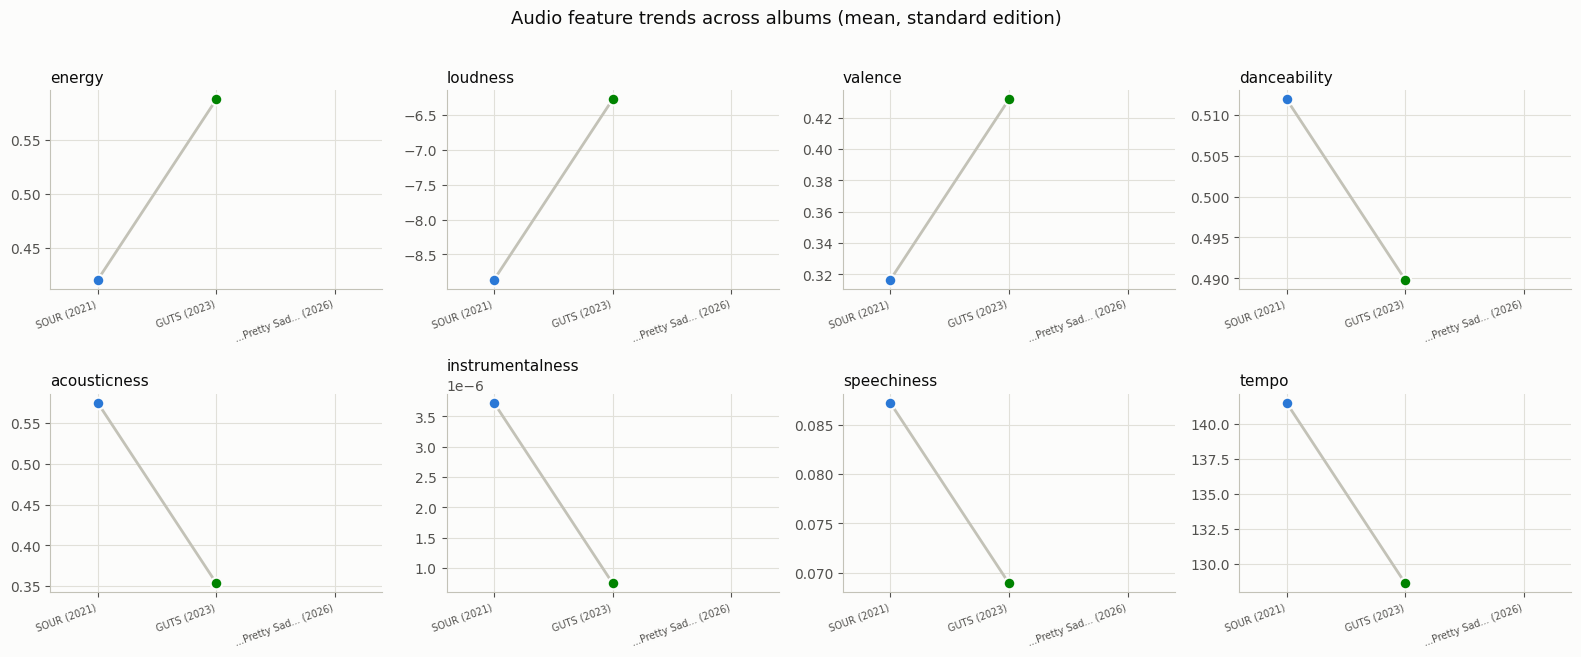

In [16]:
def plot_feature_trends(df: pd.DataFrame, features: list):
    subset = standard_edition(df)
    n_cols = 4
    n_rows = -(-len(features) // n_cols)  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows))
    axes = axes.flatten()

    for ax, feature in zip(axes, features):
        means = subset.groupby("album")[feature].mean().reindex(ALBUM_ORDER)
        if means.notna().sum() == 0:
            ax.text(0.5, 0.5, "No data yet", ha="center", va="center",
                     color="#898781", fontsize=9, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            x = list(range(len(ALBUM_ORDER)))
            ax.plot(x, means.values, color="#c3c2b7", linewidth=2, zorder=2)
            for i, album in enumerate(ALBUM_ORDER):
                ax.scatter(i, means[album], color=ALBUM_COLORS[album], s=70, zorder=3,
                            edgecolor="#fcfcfb", linewidth=1.5)
            ax.set_xticks(x)
            ax.set_xticklabels([ALBUM_SHORT_LABELS[a] for a in ALBUM_ORDER], rotation=20, ha="right", fontsize=7)
            ax.set_xlim(-0.4, len(ALBUM_ORDER) - 0.6)
        ax.set_title(feature, fontsize=11, color="#0b0b0b", loc="left")

    for ax in axes[len(features):]:
        ax.axis("off")

    fig.suptitle("Audio feature trends across albums (mean, standard edition)", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


plot_feature_trends(tracks_clean, AUDIO_FEATURES)

### 3.3 Production-complexity proxies

Three focused panels: **loudness variability** (a caveat up front — Spotify-style `loudness` is a single averaged dB value per track, not a true dynamic-range/LUFS measurement, so within-album standard deviation is used here only as a rough proxy for how much loudness varies release to release, not real dynamic range), **energy vs. valence** (mood/intensity shift), and **acousticness vs. instrumentalness** (organic vs. produced/electronic density). Each of the two scatter panels is genuinely multi-series (one color per album), so both carry a legend.

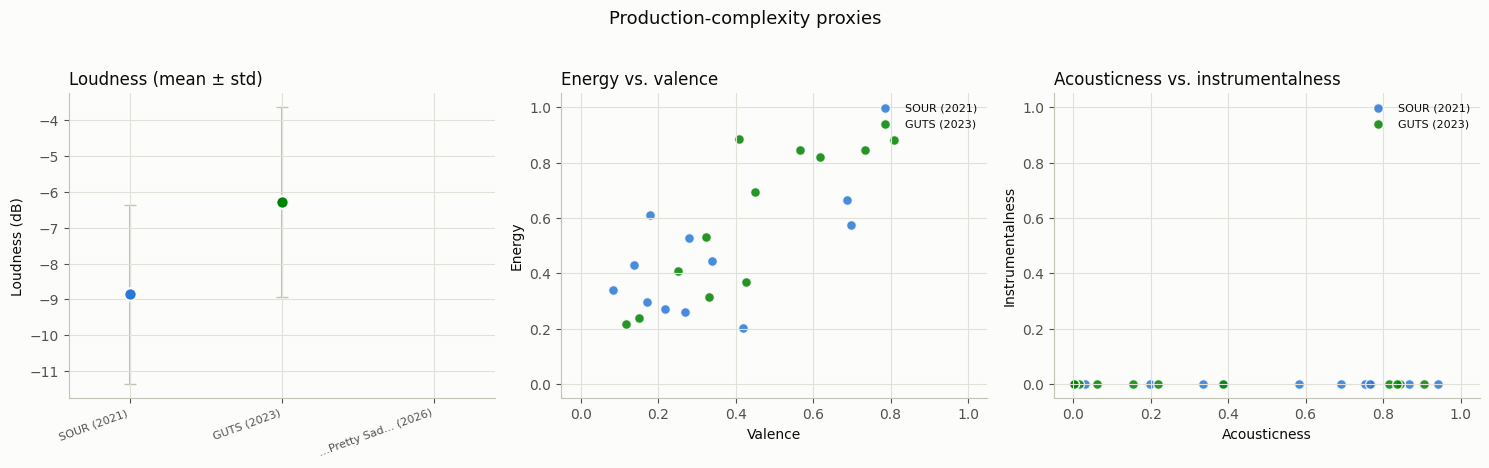

In [17]:
def _scatter_panel(ax, subset, x_col, y_col, title):
    plotted_any = False
    for album in ALBUM_ORDER:
        album_df = subset[subset["album"] == album].dropna(subset=[x_col, y_col])
        if album_df.empty:
            continue
        plotted_any = True
        ax.scatter(album_df[x_col], album_df[y_col], color=ALBUM_COLORS[album], s=50, alpha=0.85,
                    edgecolor="#fcfcfb", linewidth=1, label=ALBUM_SHORT_LABELS[album])
    if not plotted_any:
        ax.text(0.5, 0.5, "No data yet", ha="center", va="center", color="#898781", transform=ax.transAxes)
    else:
        ax.legend(frameon=False, fontsize=8)
    ax.set_xlabel(x_col.capitalize())
    ax.set_ylabel(y_col.capitalize())
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, loc="left")


def plot_production_complexity(df: pd.DataFrame):
    subset = standard_edition(df)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    ax = axes[0]
    loud_mean = subset.groupby("album")["loudness"].mean().reindex(ALBUM_ORDER)
    loud_std = subset.groupby("album")["loudness"].std().reindex(ALBUM_ORDER)
    if loud_mean.notna().sum() == 0:
        ax.text(0.5, 0.5, "No data yet", ha="center", va="center", color="#898781", transform=ax.transAxes)
        ax.set_xticks([])
    else:
        x = list(range(len(ALBUM_ORDER)))
        ax.errorbar(x, loud_mean.values, yerr=loud_std.values, fmt="none", ecolor="#c3c2b7", capsize=4, zorder=1)
        for i, album in enumerate(ALBUM_ORDER):
            ax.scatter(i, loud_mean[album], color=ALBUM_COLORS[album], s=80, zorder=3,
                        edgecolor="#fcfcfb", linewidth=1.5)
        ax.set_xticks(x)
        ax.set_xticklabels([ALBUM_SHORT_LABELS[a] for a in ALBUM_ORDER], rotation=20, ha="right", fontsize=8)
        ax.set_xlim(-0.4, len(ALBUM_ORDER) - 0.6)
    ax.set_ylabel("Loudness (dB)")
    ax.set_title("Loudness (mean ± std)", loc="left")

    _scatter_panel(axes[1], subset, "valence", "energy", "Energy vs. valence")
    _scatter_panel(axes[2], subset, "acousticness", "instrumentalness", "Acousticness vs. instrumentalness")

    fig.suptitle("Production-complexity proxies", fontsize=13, y=1.03)
    fig.tight_layout()
    plt.show()


plot_production_complexity(tracks_clean)

### 3.4 Correlation structure per album

Whether relationships between features themselves changed over time — e.g. did loudness and energy stay tightly coupled, or did that decouple with a different production style? Each heatmap only computes a correlation once an album has at least `min_observations` tracks with every feature filled in; below that, it shows a placeholder rather than a correlation matrix built on 0–1 data points.

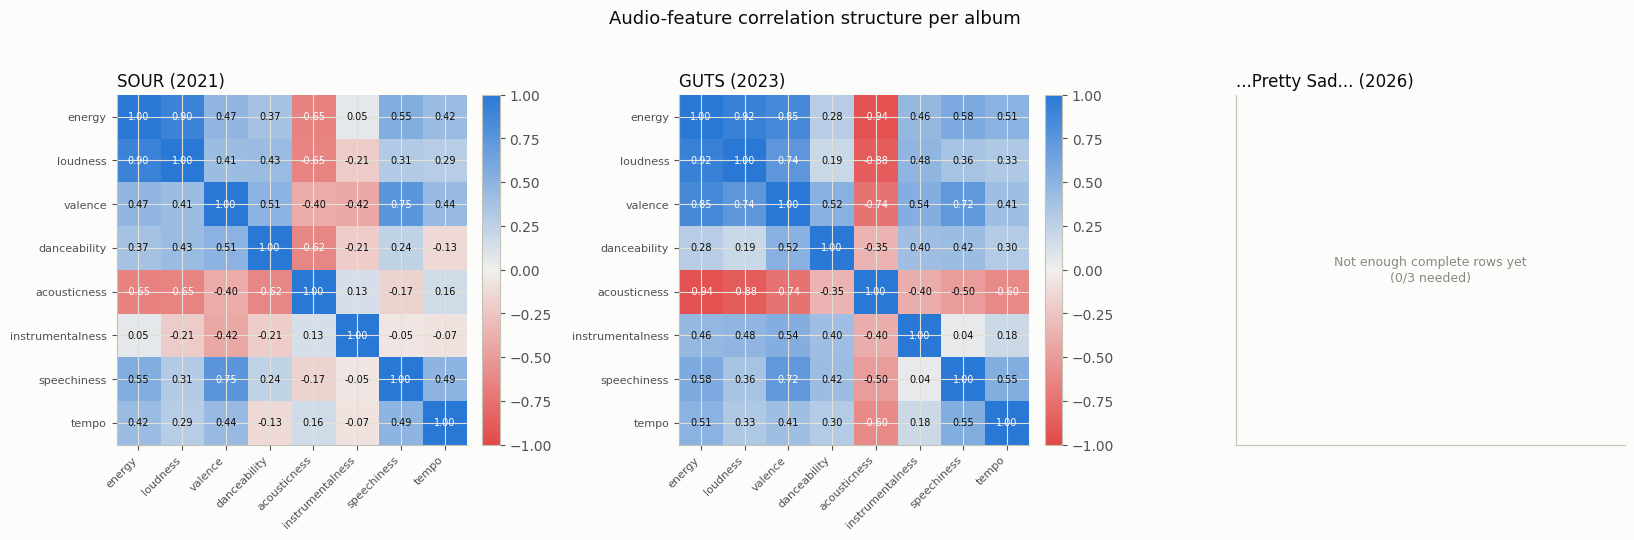

In [18]:
def plot_correlation_matrices(df: pd.DataFrame, features: list, min_observations: int = 3):
    subset = standard_edition(df)
    fig, axes = plt.subplots(1, len(ALBUM_ORDER), figsize=(5.5 * len(ALBUM_ORDER), 5))

    for ax, album in zip(axes, ALBUM_ORDER):
        complete_rows = subset.loc[subset["album"] == album, features].dropna()
        if len(complete_rows) < min_observations:
            ax.text(0.5, 0.5, f"Not enough complete rows yet\n({len(complete_rows)}/{min_observations} needed)",
                     ha="center", va="center", color="#898781", fontsize=9, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            corr = complete_rows.corr()
            im = ax.imshow(corr.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
            ax.set_xticks(range(len(features)))
            ax.set_xticklabels(features, rotation=45, ha="right", fontsize=8)
            ax.set_yticks(range(len(features)))
            ax.set_yticklabels(features, fontsize=8)
            for i in range(len(features)):
                for j in range(len(features)):
                    value = corr.values[i, j]
                    text_color = "#ffffff" if abs(value) > 0.6 else "#0b0b0b"
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7, color=text_color)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(ALBUM_SHORT_LABELS[album], loc="left")

    fig.suptitle("Audio-feature correlation structure per album", fontsize=13, y=1.03)
    fig.tight_layout()
    plt.show()


plot_correlation_matrices(tracks_clean, AUDIO_FEATURES)

## 4. Engagement Correlation

Tests whether the production-related audio features actually associate with audience engagement — Spotify popularity (all tracks) and Billboard Hot 100 peak position (the 9 tracks that were singles). Deliberately simple and explainable: Pearson and Spearman correlation coefficients and scatter plots with a linear trend line — no black-box models, since the goal is a narrative a reader can follow and check by eye, not a prediction.

**Chart peak position needs a sign flip to read intuitively**: position 1 is the *best* outcome, so a raw correlation with peak position has an inverted sign from what most readers expect. Every correlation against peak position below negates the peak first, so a positive coefficient always means "associated with better chart performance" — labeled explicitly wherever it appears.

**"Production polish" composite**, used only for the counterintuitive-finding check below: an equal-weighted average of z-scored energy, loudness, and inverted acousticness (higher = more processed/energetic/less raw). It's a simple, transparent stand-in for "how polished/maximal a track sounds" — not a validated production-quality metric, and the notebook only ever uses it to rank tracks relative to each other within this dataset, not as an absolute score.

In [19]:
from scipy import stats

# Reloaded from disk, same independent-stage principle as Section 2 — chart_peaks.csv
# isn't Spotify content, so unlike popularity it persists fine across sessions.
chart_peaks = pd.read_csv(RAW_DIR / "chart_peaks.csv")

engagement_df = tracks_clean.merge(
    chart_peaks[["album", "single", "billboard_hot100_peak"]],
    left_on=["album", "title"], right_on=["album", "single"], how="left",
).drop(columns=["single"])

n_singles = engagement_df["billboard_hot100_peak"].notna().sum()
n_popularity = engagement_df["spotify_popularity"].notna().sum()
print(f"{len(engagement_df)} tracks total | {n_singles} matched to a charting single | "
      f"{n_popularity} have a Spotify popularity score")
engagement_df[["album", "title", "spotify_popularity", "billboard_hot100_peak"]].head(12)

42 tracks total | 9 matched to a charting single | 0 have a Spotify popularity score


,album,title,spotify_popularity,billboard_hot100_peak
0,SOUR,Brutal,NaN,NaN
1,SOUR,Traitor,NaN,NaN
2,SOUR,Drivers License,NaN,1.0
3,SOUR,"1 Step Forward, 3 Steps Back",NaN,NaN
4,SOUR,Deja Vu,NaN,3.0
5,SOUR,Good 4 U,NaN,1.0
6,SOUR,Enough for You,NaN,NaN
7,SOUR,Happier,NaN,NaN
8,SOUR,"Jealousy, Jealousy",NaN,NaN
9,SOUR,Favorite Crime,NaN,NaN


### 4.1 Pearson / Spearman correlation vs. engagement

In [20]:
def correlate_with_engagement(df: pd.DataFrame, features: list, engagement_col: str,
                                higher_is_better: bool = True) -> pd.DataFrame:
    """
    Pearson and Spearman correlation between each feature and an engagement metric.
    Only rows where both the feature and the metric are present are used, and each
    row reports its own `n` since coverage varies feature to feature. If
    higher_is_better is False (peak chart position, where 1 is best), the metric is
    negated first so a positive coefficient always means "better performance."
    """
    rows = []
    for feature in features:
        paired = df[[feature, engagement_col]].dropna()
        n = len(paired)
        if n < 3:
            rows.append({"feature": feature, "n": n, "pearson_r": np.nan, "pearson_p": np.nan,
                         "spearman_r": np.nan, "spearman_p": np.nan})
            continue
        x = paired[feature]
        y = paired[engagement_col] if higher_is_better else -paired[engagement_col]
        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)
        rows.append({"feature": feature, "n": n, "pearson_r": pearson_r, "pearson_p": pearson_p,
                     "spearman_r": spearman_r, "spearman_p": spearman_p})
    return pd.DataFrame(rows).set_index("feature")


popularity_corr = correlate_with_engagement(engagement_df, AUDIO_FEATURES, "spotify_popularity", higher_is_better=True)
print("--- vs. Spotify popularity (positive = associated with HIGHER popularity) ---")
print(popularity_corr.round(3))

chart_corr = correlate_with_engagement(engagement_df, AUDIO_FEATURES, "billboard_hot100_peak", higher_is_better=False)
print("\n--- vs. Billboard Hot 100 peak, sign-flipped (positive = associated with a BETTER/lower peak) ---")
print(chart_corr.round(3))

--- vs. Spotify popularity (positive = associated with HIGHER popularity) ---
                  n  pearson_r  pearson_p  spearman_r  spearman_p
feature                                                          
energy            0        NaN        NaN         NaN         NaN
loudness          0        NaN        NaN         NaN         NaN
valence           0        NaN        NaN         NaN         NaN
danceability      0        NaN        NaN         NaN         NaN
acousticness      0        NaN        NaN         NaN         NaN
instrumentalness  0        NaN        NaN         NaN         NaN
speechiness       0        NaN        NaN         NaN         NaN
tempo             0        NaN        NaN         NaN         NaN

--- vs. Billboard Hot 100 peak, sign-flipped (positive = associated with a BETTER/lower peak) ---
                  n  pearson_r  pearson_p  spearman_r  spearman_p
feature                                                          
energy            6     -0.844 

### 4.2 Scatter plots with trend lines (feature vs. popularity)

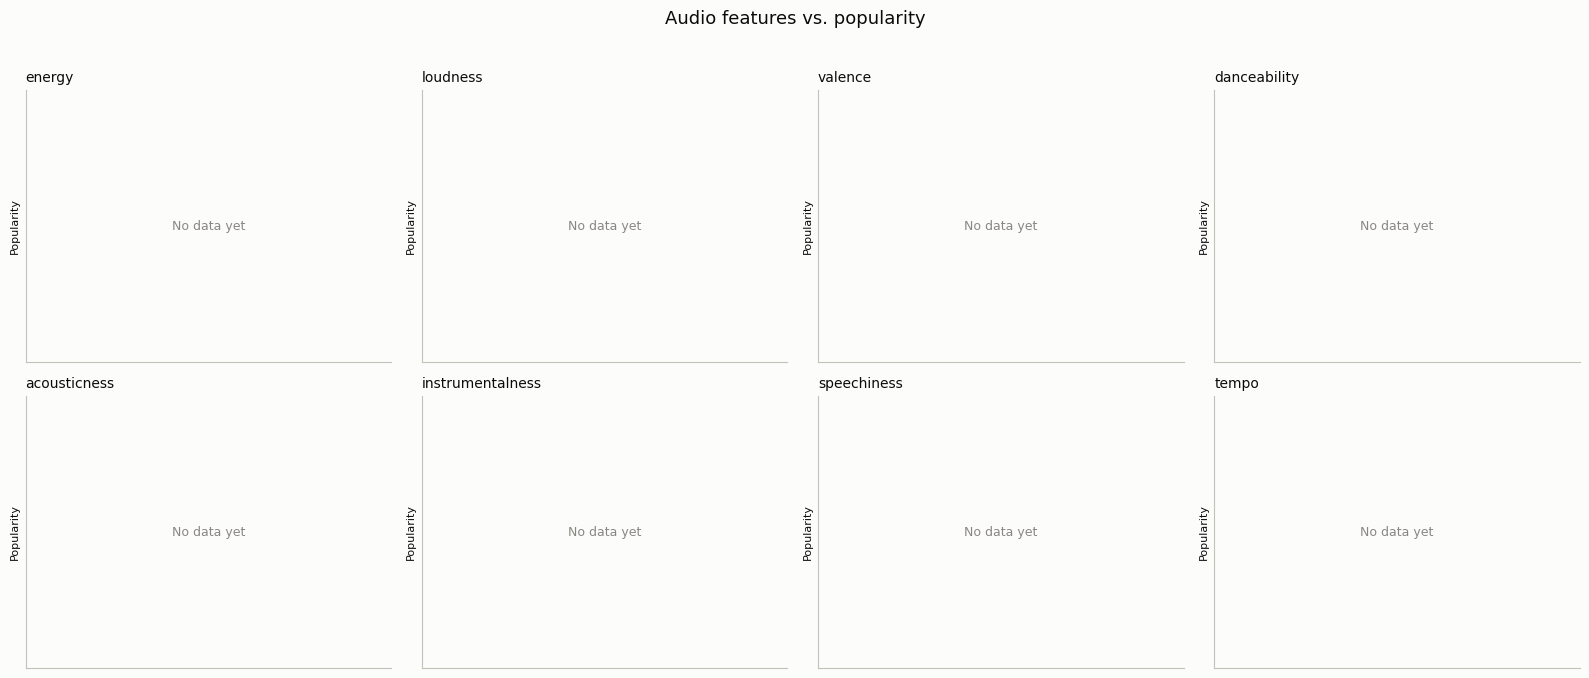

In [21]:
def plot_engagement_scatter(df: pd.DataFrame, features: list, engagement_col: str, ylabel: str):
    n_cols = 4
    n_rows = -(-len(features) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.3 * n_rows))
    axes = axes.flatten()

    for ax, feature in zip(axes, features):
        paired = df[[feature, engagement_col, "album"]].dropna(subset=[feature, engagement_col])
        if len(paired) < 3:
            ax.text(0.5, 0.5, "No data yet", ha="center", va="center", color="#898781",
                     fontsize=9, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            for album in ALBUM_ORDER:
                pts = paired[paired["album"] == album]
                if pts.empty:
                    continue
                ax.scatter(pts[feature], pts[engagement_col], color=ALBUM_COLORS[album], s=40,
                            alpha=0.85, edgecolor="#fcfcfb", linewidth=1, zorder=2)
            coeffs = np.polyfit(paired[feature], paired[engagement_col], 1)
            xs = np.linspace(paired[feature].min(), paired[feature].max(), 50)
            ax.plot(xs, np.polyval(coeffs, xs), color="#52514e", linewidth=1.5, linestyle="--", zorder=1)
        ax.set_title(feature, fontsize=10, loc="left")
        ax.set_ylabel(ylabel, fontsize=8)

    for ax in axes[len(features):]:
        ax.axis("off")

    fig.suptitle(f"Audio features vs. {ylabel.lower()}", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


plot_engagement_scatter(engagement_df, AUDIO_FEATURES, "spotify_popularity", "Popularity")

### 4.3 Counterintuitive findings

Ranks every track by the "production polish" composite defined above and separately by popularity, then surfaces the tracks with the biggest gap between the two ranks — a rawer-sounding track that still out-performs a more polished one, or vice versa. This is entirely data-driven: with the manual audio-feature columns still blank, it reports that plainly rather than inventing an example.

In [22]:
def find_counterintuitive_tracks(df: pd.DataFrame, complexity_features: list, popularity_col: str,
                                   top_n: int = 3, min_tracks: int = 5):
    """
    Builds the 'production polish' composite (see Section 4 intro), ranks tracks by
    it and separately by popularity, and surfaces the largest rank gaps — the
    concrete counterintuitive cases the article is looking for. Prints real numbers
    for each flagged track. Refuses to rank anything on fewer than `min_tracks`
    complete rows rather than draw a conclusion from a handful of points.
    """
    needed = complexity_features + [popularity_col]
    usable = df.dropna(subset=needed).copy()
    if len(usable) < min_tracks:
        print(f"Only {len(usable)}/{len(df)} tracks have every needed field filled in "
              f"({needed}) — need at least {min_tracks} to rank meaningfully. Fill in the "
              f"manual audio-feature columns in /data/raw and re-run Sections 2-4.")
        return None

    z = (usable[complexity_features] - usable[complexity_features].mean()) / usable[complexity_features].std()
    usable["production_polish"] = (z["energy"] + z["loudness"] - z["acousticness"]) / 3
    usable["polish_rank"] = usable["production_polish"].rank(ascending=False)
    usable["popularity_rank"] = usable[popularity_col].rank(ascending=False)
    usable["rank_gap"] = usable["popularity_rank"] - usable["polish_rank"]

    flagged = usable.reindex(usable["rank_gap"].abs().sort_values(ascending=False).index).head(top_n)
    print(f"Top {len(flagged)} gaps between production polish and popularity (of {len(usable)} ranked tracks):\n")
    for _, row in flagged.iterrows():
        direction = "LESS polished but MORE popular" if row["rank_gap"] < 0 else "MORE polished but LESS popular"
        print(f"  '{row['title']}' ({row['album']}): polish rank {int(row['polish_rank'])}/{len(usable)}, "
              f"popularity rank {int(row['popularity_rank'])}/{len(usable)} "
              f"(popularity score {row[popularity_col]:.0f}) — {direction} than its production score predicts.")
    return flagged


counterintuitive_tracks = find_counterintuitive_tracks(
    engagement_df, ["energy", "loudness", "acousticness"], "spotify_popularity"
)

Only 0/42 tracks have every needed field filled in (['energy', 'loudness', 'acousticness', 'spotify_popularity']) — need at least 5 to rank meaningfully. Fill in the manual audio-feature columns in /data/raw and re-run Sections 2-4.
